# Integración de atributos OSM en la red VISUM

Esta notebook transfiere los atributos viales de la red de OpenStreetMap previamente caracterizada hacia la red utilizada en VISUM.

In [12]:
from pathlib import Path
import folium
import geopandas as gpd
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

mpl.rc("text", usetex=True)
mpl.rc("font", family="serif")

### Lectura de las redes viales

Cargamos la red OSM y la red de links exportada desde VISUM.

In [ ]:
ruta_datos = Path("/Users/.../asignacion_atributos")

red_osm = gpd.read_file(ruta_datos / "resultados_asignacion_atributos/asignacion_atributos_red_vial_completa/red_vial_completa.shp")
red_visum = gpd.read_file(ruta_datos / "datos_asignacion_atributos/links_from_visum.shp")

print(f"Links OSM: {len(red_osm):,} | CRS: {red_osm.crs}")
print(f"Links VISUM: {len(red_visum):,} | CRS: {red_visum.crs}")

Links OSM: 451,685 | CRS: EPSG:4326
Links VISUM: 593,968 | CRS: EPSG:4326


### Homologación de las llaves para enlazar las redes

La correspondencia entre ambas redes se realizará con la llave: `U`, `V` y `KEY`. Los convertimos a enteros en la red VISUM.

In [4]:
columnas_llave = ["U", "V", "KEY"]
red_visum[columnas_llave] = red_visum[columnas_llave].apply(pd.to_numeric, errors="raise").astype("int64")

### Preparación de los atributos de OSM

Seleccionamos de la red OSM la llave de cada link y los cuatro atributos requeridos por el modelo:

- capacidad
- número de carriles
- velocidad promedio
- límite de velocidad.

Como consideración importante, eliminamos registros sin una llave completa y se convierten los identificadores a números enteros.

In [6]:
atributos_osm = red_osm[["u", "v", "key", "cap_final", "carr_final", "velprom_fi", "vel_final"]].rename(columns={"u": "U", "v": "V", "key": "KEY"}).copy()
atributos_osm = atributos_osm.dropna(subset=columnas_llave)
atributos_osm[columnas_llave] = atributos_osm[columnas_llave].apply(pd.to_numeric, errors="raise").astype("int64")

### Integración de los atributos OSM en la red VISUM

Los atributos de la red OSM los integramos mediante una unión (izquierda) sobre la llave `U`, `V` y `KEY`. Este tipo de unión conserva todos los links originales de VISUM, independientemente de que tengan o no una correspondencia en OSM. La columna `con_osm` muestra:

- `1`: el link de VISUM encontró una correspondencia en OSM
- `0`: el link de VISUM no encontró una correspondencia

In [8]:
red_visum_atributos = red_visum.merge(atributos_osm, on=columnas_llave, how="left", validate="many_to_one", indicator=True)

red_visum_atributos["con_osm"] = red_visum_atributos["_merge"].eq("both").astype("int8")
red_visum_atributos = red_visum_atributos.drop(columns="_merge")
red_visum_atributos = gpd.GeoDataFrame(red_visum_atributos, geometry="geometry", crs=red_visum.crs)

### Tratamiento de links sin correspondencia OSM

Para los registros sin correspondencia, los atributos provenientes de OSM se sustituyen por cero. La columna `con_osm` nos permite distinguir entre un valor transferido desde OSM y un cero asignado por ausencia de correspondencia.

In [10]:
columnas_atributos = ["cap_final", "carr_final", "velprom_fi", "vel_final"]
red_visum_atributos[columnas_atributos] = red_visum_atributos[columnas_atributos].fillna(0)

### Estructura de la red VISUM integrada

Estas son las columnas y algunos de los registros de la red.

In [ ]:
columnas_muestra = ["U", "V", "KEY", "cap_final", "carr_final", "velprom_fi", "vel_final", "con_osm", "geometry"]

print(red_visum_atributos.columns.tolist())
display(red_visum_atributos[columnas_muestra].head())

['No', 'FromNodeNo', 'ToNodeNo', 'TypeNo', 'TSysSet', 'Length', 'U', 'V', 'KEY', 'HIGHWAY', 'geometry', 'cap_final', 'carr_final', 'velprom_fi', 'vel_final', 'con_osm']


,U,V,KEY,cap_final,carr_final,velprom_fi,vel_final,con_osm,geometry
0,267537966,7306651630,0,4000.0,2.0,24.000000,30.0,1,"LINESTRING (-103.2463 20.6161, -103.2473 20.61..."
1,0,0,0,0.0,0.0,0.000000,0.0,0,"LINESTRING (-103.2905 20.6279, -103.2894 20.62..."
2,267537966,5837556433,0,4000.0,2.0,23.999956,30.0,1,"LINESTRING (-103.2463 20.6161, -103.2465 20.61..."
3,0,0,0,0.0,0.0,0.000000,0.0,0,"LINESTRING (-103.2477 20.6163, -103.2475 20.61..."
4,267538751,273140976,0,2500.0,1.0,53.999923,80.0,1,"LINESTRING (-103.1364 20.6056, -103.1343 20.60..."


### Comparación entre las redes OSM y VISUM

Esta figura compara la red OSM con la red de VISUM, junto con el resultado de la integración.

En el tercer panel, los links de VISUM se clasifican según el resultado de la unión:

- azul: links con correspondencia en la red OSM
- gris: links sin correspondencia en la red OSM

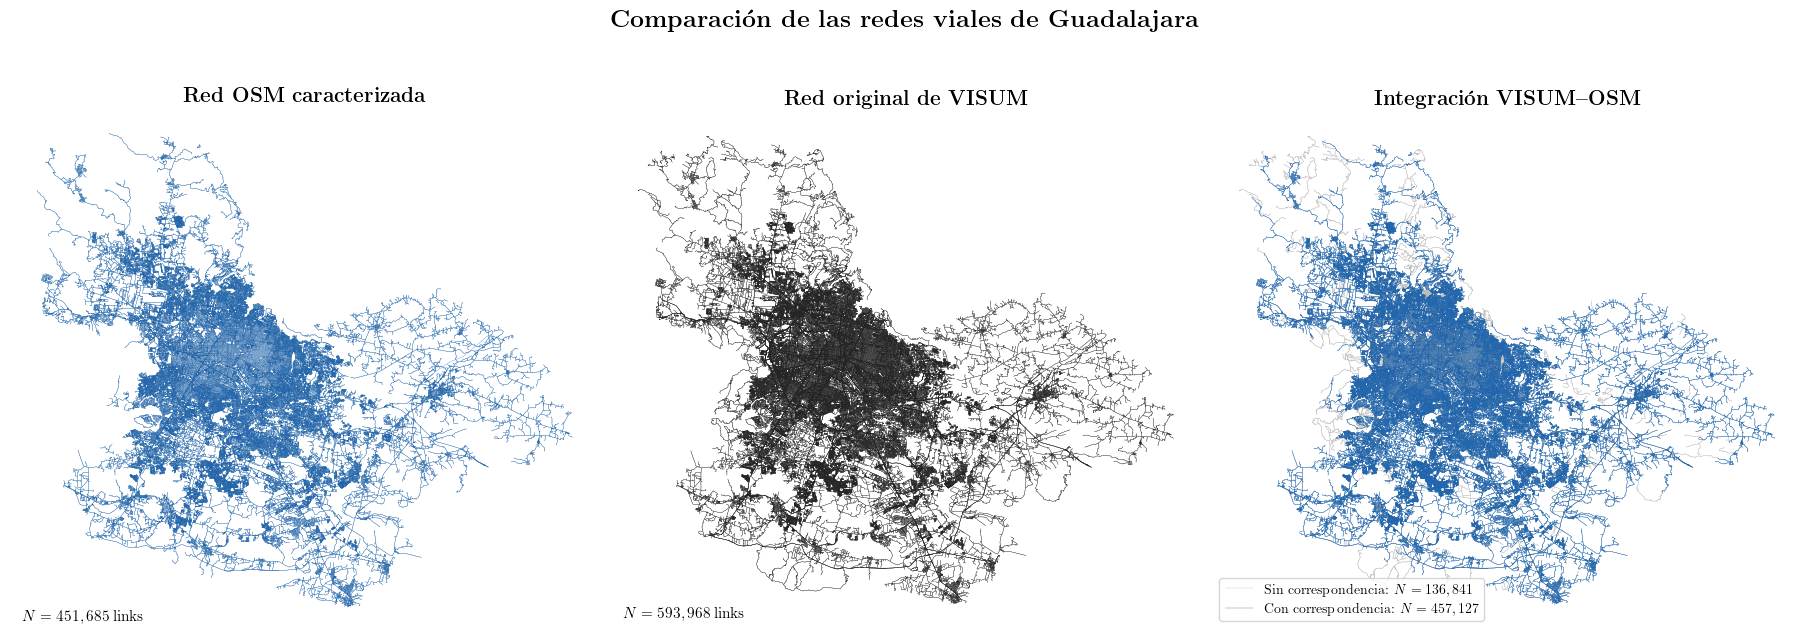

,resultado,links,porcentaje
0,Con correspondencia OSM,"457,127",76.96%
1,Sin correspondencia OSM,"136,841",23.04%


In [14]:
osm_plot = red_osm[["u", "v", "key", "cap_final", "carr_final", "velprom_fi", "vel_final", "geometry"]].copy()
visum_con_osm_plot = red_visum_atributos.loc[red_visum_atributos["con_osm"] == 1, ["U", "V", "KEY", "cap_final", "carr_final", "velprom_fi", "vel_final", "con_osm", "geometry"]].copy()
visum_sin_osm_plot = red_visum_atributos.loc[red_visum_atributos["con_osm"] == 0, ["U", "V", "KEY", "cap_final", "carr_final", "velprom_fi", "vel_final", "con_osm", "geometry"]].copy()

crs_metrico = "EPSG:32613"

osm_plot_metrico = osm_plot.to_crs(crs_metrico)
visum_con_osm_plot_metrico = visum_con_osm_plot.to_crs(crs_metrico)
visum_sin_osm_plot_metrico = visum_sin_osm_plot.to_crs(crs_metrico)

fig, axes = plt.subplots(1, 3, figsize=(18, 7), constrained_layout=True)

osm_plot_metrico.plot(ax=axes[0], color="#2166ac", linewidth=0.20)
axes[0].set_title(r"\textbf{Red OSM caracterizada}", fontsize=15)
axes[0].text(0.02, 0.02, rf"$N={len(osm_plot_metrico):,}$ links", transform=axes[0].transAxes, fontsize=11, bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"))

red_visum.to_crs(crs_metrico).plot(ax=axes[1], color="#252525", linewidth=0.20)
axes[1].set_title(r"\textbf{Red original de VISUM}", fontsize=15)
axes[1].text(0.02, 0.02, rf"$N={len(red_visum):,}$ links", transform=axes[1].transAxes, fontsize=11, bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"))

visum_sin_osm_plot_metrico.plot(ax=axes[2], color="#bdbdbd", linewidth=0.25, label=rf"Sin correspondencia: $N={len(visum_sin_osm_plot_metrico):,}$")
visum_con_osm_plot_metrico.plot(ax=axes[2], color="#2166ac", linewidth=0.25, label=rf"Con correspondencia: $N={len(visum_con_osm_plot_metrico):,}$")
axes[2].set_title(r"\textbf{Integración VISUM--OSM}", fontsize=15)
axes[2].legend(loc="lower left", fontsize=10, frameon=True)

for ax in axes:
    ax.set_axis_off()

fig.suptitle(r"\textbf{Comparación de las redes viales de Guadalajara}", fontsize=18)
plt.show()

resumen_integracion = red_visum_atributos["con_osm"].value_counts().rename(index={1: "Con correspondencia OSM", 0: "Sin correspondencia OSM"}).rename_axis("resultado").reset_index(name="links")
resumen_integracion["porcentaje"] = 100 * resumen_integracion["links"] / len(red_visum_atributos)

display(resumen_integracion.style.format({"links": "{:,.0f}", "porcentaje": "{:.2f}%"}))